In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import geopandas as gpd

In [2]:
path = "F:\olist/" 

# ============================
# 2) Load كل الملفات
# ============================

orders = pd.read_csv(path + "olist_orders_dataset.csv")
order_items = pd.read_csv(path + "olist_order_items_dataset.csv")
products = pd.read_csv(path + "olist_products_dataset.csv")
customers = pd.read_csv(path + "olist_customers_dataset.csv")
payments = pd.read_csv(path + "olist_order_payments_dataset.csv")
reviews = pd.read_csv(path + "olist_order_reviews_dataset.csv")
sellers = pd.read_csv(path + "olist_sellers_dataset.csv")
geolocation = pd.read_csv(path + "olist_geolocation_dataset.csv")
category_translation = pd.read_csv(path + "product_category_name_translation.csv")

# ============================
# 3) تأكيد التحميل
# ============================

print("Orders:", orders.shape)
print("Order Items:", order_items.shape)
print("Products:", products.shape)
print("Customers:", customers.shape)
print("Payments:", payments.shape)
print("Reviews:", reviews.shape)
print("Sellers:", sellers.shape)
print("Geolocation:", geolocation.shape)
print("Category Translation:", category_translation.shape)


Orders: (99441, 8)
Order Items: (112650, 7)
Products: (32951, 9)
Customers: (99441, 5)
Payments: (103886, 5)
Reviews: (99224, 7)
Sellers: (3095, 4)
Geolocation: (1000163, 5)
Category Translation: (71, 2)


In [65]:
# merge orders with customers
orders_full = orders.merge(customers, on="customer_id", how="left")

# merge payments (sum value, max installments, mode payment type)
payment_summary = (
    payments.groupby("order_id")
    .agg({
        "payment_value": "sum",
        "payment_installments": "max",
        "payment_type": lambda x: x.mode()[0] if not x.mode().empty else None
    })
    .reset_index()
)
orders_full = orders_full.merge(payment_summary, on="order_id", how="left")

# merge reviews
orders_full = orders_full.merge(
    reviews[["order_id", "review_score", "review_comment_message", "review_creation_date"]],
    on="order_id",
    how="left"
)

# merge order_items (freight, price, product, seller)
orders_full = orders_full.merge(
    order_items[["order_id", "freight_value", "price", "product_id", "seller_id"]],
    on="order_id",
    how="left"
)

# merge products with category translation
product_info = products.merge(category_translation, on="product_category_name", how="left")
orders_full = orders_full.merge(product_info, on="product_id", how="left")

# merge sellers
orders_full = orders_full.merge(sellers, on="seller_id", how="left")

# ensure zip prefixes have the same dtype before merging
orders_full["customer_zip_code_prefix"] = orders_full["customer_zip_code_prefix"].astype(str)
geo_summary["geolocation_zip_code_prefix"] = geo_summary["geolocation_zip_code_prefix"].astype(str)

# merge geolocation (avg lat/lng per zip prefix)
orders_full = orders_full.merge(
    geo_summary,
    left_on="customer_zip_code_prefix",
    right_on="geolocation_zip_code_prefix",
    how="left"
)
orders_full = orders_full.merge(
    geo_summary,
    left_on="customer_zip_code_prefix",
    right_on="geolocation_zip_code_prefix",
    how="left"
)

# final shape check
print("orders_full shape:", orders_full.shape)
orders_full.head()


orders_full shape: (114092, 46)


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,day_in_month,delivery_time_days,...,product_category_name_english,seller_zip_code_prefix,seller_city,seller_state,geolocation_zip_code_prefix_x,geolocation_lat_x,geolocation_lng_x,geolocation_zip_code_prefix_y,geolocation_lat_y,geolocation_lng_y
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,2,8.0,...,housewares,9350,maua,SP,3149,-23.576983,-46.587161,3149,-23.576983,-46.587161
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,24,13.0,...,perfumery,31570,belo horizonte,SP,47813,-12.177924,-44.660711,47813,-12.177924,-44.660711
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,8,9.0,...,auto,14840,guariba,SP,75265,-16.745150,-48.514783,75265,-16.745150,-48.514783
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15,18,13.0,...,pet_shop,31842,belo horizonte,MG,59296,-5.774190,-35.271143,59296,-5.774190,-35.271143
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26,13,2.0,...,stationery,8752,mogi das cruzes,SP,9195,-23.676370,-46.514627,9195,-23.676370,-46.514627


In [66]:
# quick null check for any dataframe
def check_nulls(df, name):
    print(f"\n{name} — null count")
    print(df.isna().sum())

check_nulls(orders, "orders")
check_nulls(order_items, "order_items")
check_nulls(products, "products")
check_nulls(customers, "customers")
check_nulls(payments, "payments")
check_nulls(reviews, "reviews")
check_nulls(sellers, "sellers")
check_nulls(geolocation, "geolocation")



orders — null count
order_id                            0
customer_id                         0
order_status                        0
order_purchase_timestamp            0
order_approved_at                 160
order_delivered_carrier_date     1783
order_delivered_customer_date    2965
order_estimated_delivery_date       0
day_in_month                        0
delivery_time_days               2965
estimated_time_days                 0
delay_days                       2965
on_time                             0
dtype: int64

order_items — null count
order_id               0
order_item_id          0
product_id             0
seller_id              0
shipping_limit_date    0
price                  0
freight_value          0
price_range            0
dtype: int64

products — null count
product_id                      0
product_category_name           0
product_name_lenght           609
product_description_lenght    609
product_photos_qty            609
product_weight_g                0
produc

In [ ]:
# clean product table (fill missing category + drop missing dimensions)
products["product_category_name"].fillna("unknown", inplace=True)
products.dropna(
    subset=["product_weight_g", "product_length_cm", "product_height_cm", "product_width_cm"],
    inplace=True
)

# keep delivery date nulls (canceled / incomplete orders)

# keep review comment nulls (not needed for numeric analysis)


In [67]:
# quick duplicate check for any dataframe
def check_duplicates(df, name):
    print(f"{name} — duplicates:", df.duplicated().sum())

check_duplicates(orders, "orders")
check_duplicates(order_items, "order_items")
check_duplicates(products, "products")
check_duplicates(customers, "customers")
check_duplicates(payments, "payments")
check_duplicates(reviews, "reviews")
check_duplicates(sellers, "sellers")
check_duplicates(geolocation, "geolocation")



orders — duplicates: 0
order_items — duplicates: 0
products — duplicates: 0
customers — duplicates: 0
payments — duplicates: 0
reviews — duplicates: 0
sellers — duplicates: 0
geolocation — duplicates: 261831


In [7]:
def check_dtypes(df, name):
    print(f"\nDtypes in {name}:")
    print(df.dtypes)

check_dtypes(orders, "orders")
check_dtypes(order_items, "order_items")
check_dtypes(products, "products")
check_dtypes(customers, "customers")
check_dtypes(payments, "payments")
check_dtypes(reviews, "reviews")
check_dtypes(sellers, "sellers")
check_dtypes(geolocation, "geolocation")



Dtypes in orders:
order_id                         object
customer_id                      object
order_status                     object
order_purchase_timestamp         object
order_approved_at                object
order_delivered_carrier_date     object
order_delivered_customer_date    object
order_estimated_delivery_date    object
dtype: object

Dtypes in order_items:
order_id                object
order_item_id            int64
product_id              object
seller_id               object
shipping_limit_date     object
price                  float64
freight_value          float64
dtype: object

Dtypes in products:
product_id                     object
product_category_name          object
product_name_lenght           float64
product_description_lenght    float64
product_photos_qty            float64
product_weight_g              float64
product_length_cm             float64
product_height_cm             float64
product_width_cm              float64
dtype: object

Dtypes in cust

In [68]:
# convert order date columns to datetime
date_cols = [
    "order_purchase_timestamp",
    "order_approved_at",
    "order_delivered_carrier_date",
    "order_delivered_customer_date",
    "order_estimated_delivery_date"
]
orders[date_cols] = orders[date_cols].apply(pd.to_datetime, errors="coerce")

# convert shipping limit date
order_items["shipping_limit_date"] = pd.to_datetime(order_items["shipping_limit_date"], errors="coerce")

# ensure zip prefixes are strings
customers["customer_zip_code_prefix"] = customers["customer_zip_code_prefix"].astype(str)
sellers["seller_zip_code_prefix"] = sellers["seller_zip_code_prefix"].astype(str)

# convert review dates
reviews["review_creation_date"] = pd.to_datetime(reviews["review_creation_date"], errors="coerce")
reviews["review_answer_timestamp"] = pd.to_datetime(reviews["review_answer_timestamp"], errors="coerce")


# ============================================================
# 📦 Orders Overview — Final Insights
# ============================================================


In [69]:
# total unique orders
total_orders = orders["order_id"].nunique()
total_orders


99441

In [10]:
orders.head(
)

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26


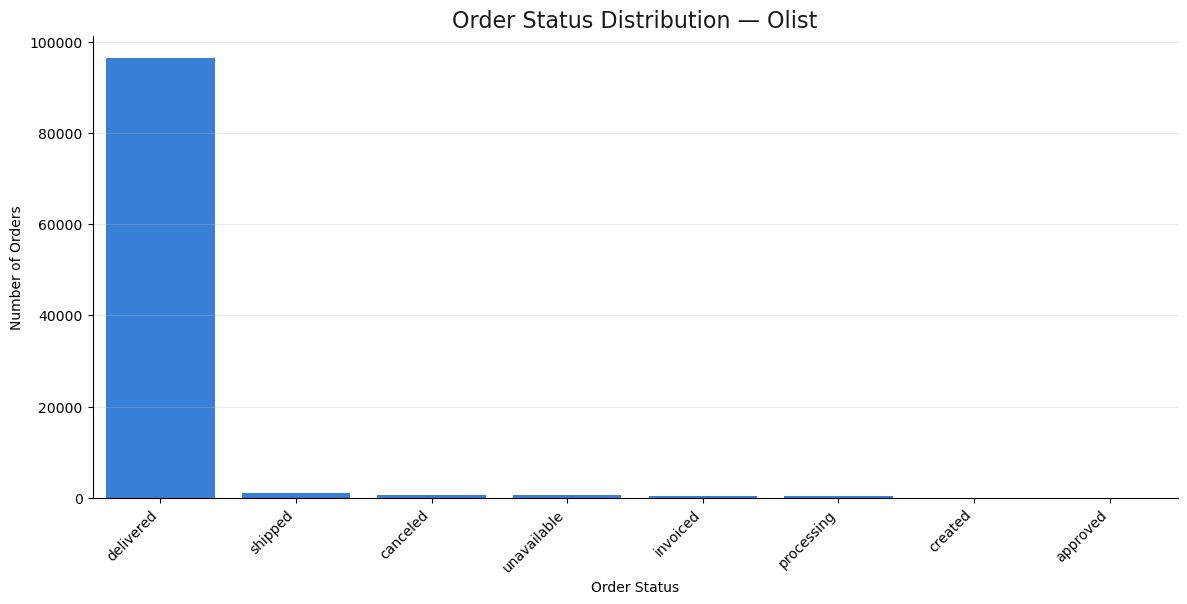

In [74]:
# Order status counts
order_status_counts = orders["order_status"].value_counts().reset_index()
order_status_counts.columns = ["order_status", "count"]
order_status_counts = order_status_counts.sort_values("count", ascending=False)

# Bar chart
plt.figure(figsize=(14,6))
sns.barplot(
    data=order_status_counts,
    x="order_status",
    y="count",
    color="#1D7CF2"
)

plt.title("Order Status Distribution — Olist", fontsize=16, color="#1A1A1A")
plt.xlabel("Order Status")
plt.ylabel("Number of Orders")

plt.xticks(rotation=45, ha="right")
plt.grid(axis="y", alpha=0.3, color="#BDBDBD")

sns.despine()
plt.show()


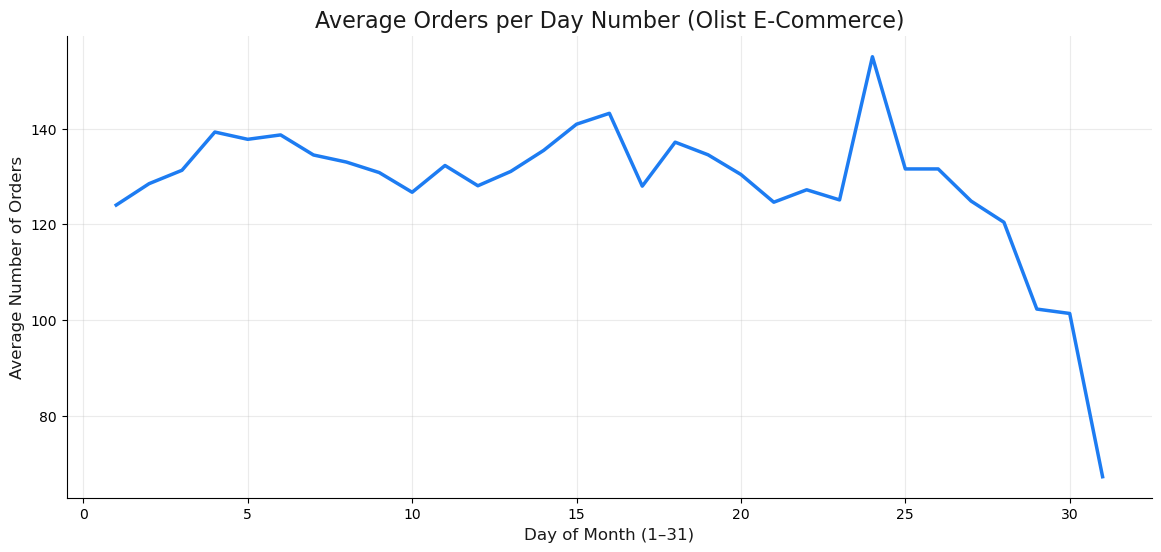

In [75]:
# monthly day-level aggregation
orders["day_in_month"] = orders["order_purchase_timestamp"].dt.day

daily_pattern = (
    orders.groupby("day_in_month")["order_id"]
    .count()
    .reset_index()
    .rename(columns={"order_id": "orders_count"})
)

months_count = orders["order_purchase_timestamp"].dt.to_period("M").nunique()
daily_pattern["avg_orders_per_day"] = daily_pattern["orders_count"] / months_count

daily_pattern = daily_pattern.sort_values("day_in_month")

plt.figure(figsize=(14,6))
sns.lineplot(
    data=daily_pattern,
    x="day_in_month",
    y="avg_orders_per_day",
    color="#1D7CF2",
    linewidth=2.5
)

plt.title("Average Orders per Day Number (Olist E-Commerce)", fontsize=16, color="#1A1A1A")
plt.xlabel("Day of Month (1–31)", fontsize=12, color="#1A1A1A")
plt.ylabel("Average Number of Orders", fontsize=12, color="#1A1A1A")

plt.grid(alpha=0.3, color="#BDBDBD")
sns.despine()

plt.show()


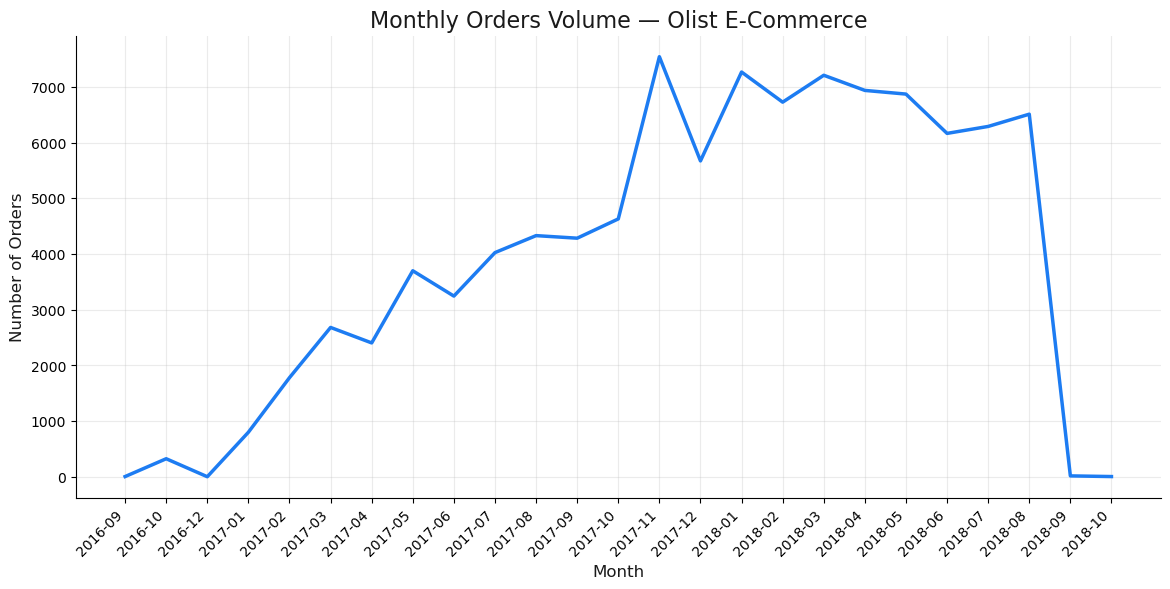

In [76]:
# monthly orders volume
monthly_orders = orders.groupby(
    orders["order_purchase_timestamp"].dt.to_period("M")
)["order_id"].count().reset_index()

monthly_orders.columns = ["month", "orders_count"]
monthly_orders["month"] = monthly_orders["month"].astype(str)

plt.figure(figsize=(14,6))
sns.lineplot(
    data=monthly_orders,
    x="month",
    y="orders_count",
    color="#1D7CF2",
    linewidth=2.5
)

plt.title("Monthly Orders Volume — Olist E-Commerce", fontsize=16, color="#1A1A1A")
plt.xlabel("Month", fontsize=12, color="#1A1A1A")
plt.ylabel("Number of Orders", fontsize=12, color="#1A1A1A")

plt.xticks(rotation=45, ha="right")
plt.grid(alpha=0.3, color="#BDBDBD")
sns.despine()

plt.show()


In [14]:
orders_full.head()


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_unique_id,customer_zip_code_prefix,...,product_length_cm,product_height_cm,product_width_cm,product_category_name_english,seller_zip_code_prefix,seller_city,seller_state,geolocation_zip_code_prefix,geolocation_lat,geolocation_lng
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,7c396fd4830fd04220f754e42b4e5bff,3149,...,19.0,8.0,13.0,housewares,9350.0,maua,SP,3149.0,-23.576983,-46.587161
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00,af07308b275d755c9edb36a90c618231,47813,...,19.0,13.0,19.0,perfumery,31570.0,belo horizonte,SP,47813.0,-12.177924,-44.660711
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00,3a653a41f6f9fc3d2a113cf8398680e8,75265,...,24.0,19.0,21.0,auto,14840.0,guariba,SP,75265.0,-16.745150,-48.514783
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00,7c142cf63193a1473d2e66489a9ae977,59296,...,30.0,10.0,20.0,pet_shop,31842.0,belo horizonte,MG,59296.0,-5.774190,-35.271143
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00,72632f0f9dd73dfee390c9b22eb56dd6,9195,...,51.0,15.0,15.0,stationery,8752.0,mogi das cruzes,SP,9195.0,-23.676370,-46.514627


In [15]:
orders_full.columns


Index(['order_id', 'customer_id', 'order_status', 'order_purchase_timestamp',
       'order_approved_at', 'order_delivered_carrier_date',
       'order_delivered_customer_date', 'order_estimated_delivery_date',
       'customer_unique_id', 'customer_zip_code_prefix', 'customer_city',
       'customer_state', 'payment_value', 'payment_installments',
       'payment_type', 'review_score', 'review_comment_message',
       'review_creation_date', 'freight_value', 'price', 'product_id',
       'seller_id', 'product_category_name', 'product_name_lenght',
       'product_description_lenght', 'product_photos_qty', 'product_weight_g',
       'product_length_cm', 'product_height_cm', 'product_width_cm',
       'product_category_name_english', 'seller_zip_code_prefix',
       'seller_city', 'seller_state', 'geolocation_zip_code_prefix',
       'geolocation_lat', 'geolocation_lng'],
      dtype='object')

Order Value — Descriptive Statistics:
count    114089.000000
mean        180.382544
std         273.066275
min           0.000000
25%          65.630000
50%         114.330000
75%         195.390000
max       13664.080000
Name: payment_value, dtype: float64

Mean Order Value: 180.38254354056917
Median Order Value: 114.33

Number of zero-value orders: 3
Orders above 500 (potential outliers): 6276

Order Value Quantiles:
0.25     65.630
0.50    114.330
0.75    195.390
0.90    349.022
0.95    534.190
Name: payment_value, dtype: float64


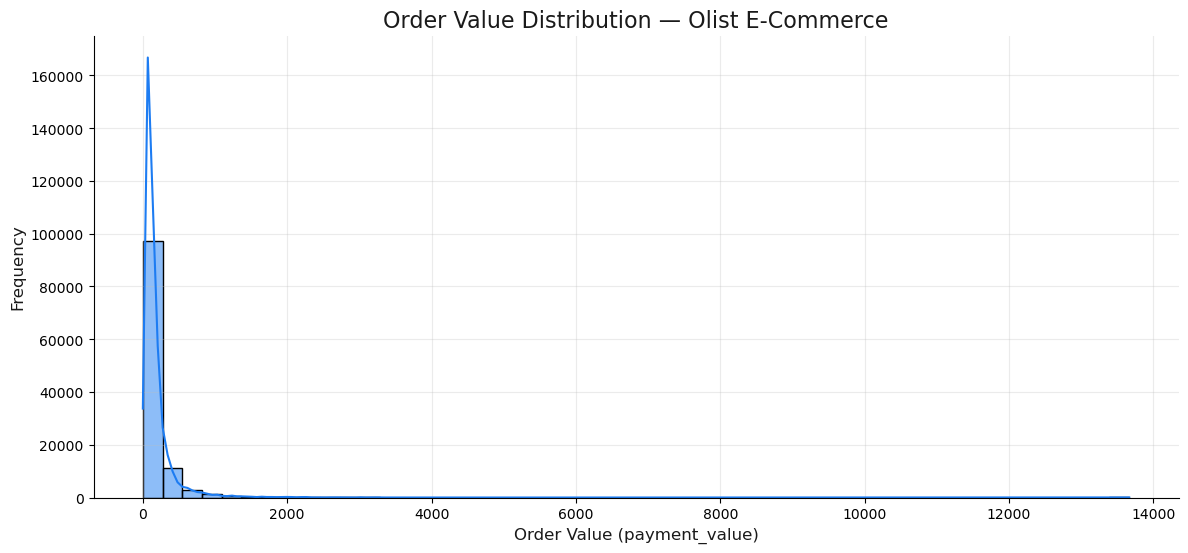

In [77]:
# order value — basic analysis
order_value_stats = orders_full["payment_value"].describe()
print("Order Value — Descriptive Statistics:")
print(order_value_stats)

mean_value = orders_full["payment_value"].mean()
median_value = orders_full["payment_value"].median()
print("\nMean Order Value:", mean_value)
print("Median Order Value:", median_value)

zero_value_orders = (orders_full["payment_value"] == 0).sum()
print("\nNumber of zero-value orders:", zero_value_orders)

high_value_orders = (orders_full["payment_value"] > 500).sum()
print("Orders above 500 (potential outliers):", high_value_orders)

quantiles = orders_full["payment_value"].quantile([0.25, 0.50, 0.75, 0.90, 0.95])
print("\nOrder Value Quantiles:")
print(quantiles)

# histogram
plt.figure(figsize=(14,6))
sns.histplot(
    data=orders_full,
    x="payment_value",
    bins=50,
    kde=True,
    color="#1D7CF2"
)

plt.title("Order Value Distribution — Olist E-Commerce", fontsize=16, color="#1A1A1A")
plt.xlabel("Order Value (payment_value)", fontsize=12, color="#1A1A1A")
plt.ylabel("Frequency", fontsize=12, color="#1A1A1A")

plt.grid(alpha=0.3, color="#BDBDBD")
sns.despine()

plt.show()


Freight Value — Descriptive Statistics:
count    113314.000000
mean         19.979428
std          15.783227
min           0.000000
25%          13.080000
50%          16.260000
75%          21.150000
max         409.680000
Name: freight_value, dtype: float64

Mean Freight Value: 19.979427519988707
Median Freight Value: 16.26
Zero Freight Orders: 383
Orders > 200 BRL: 70


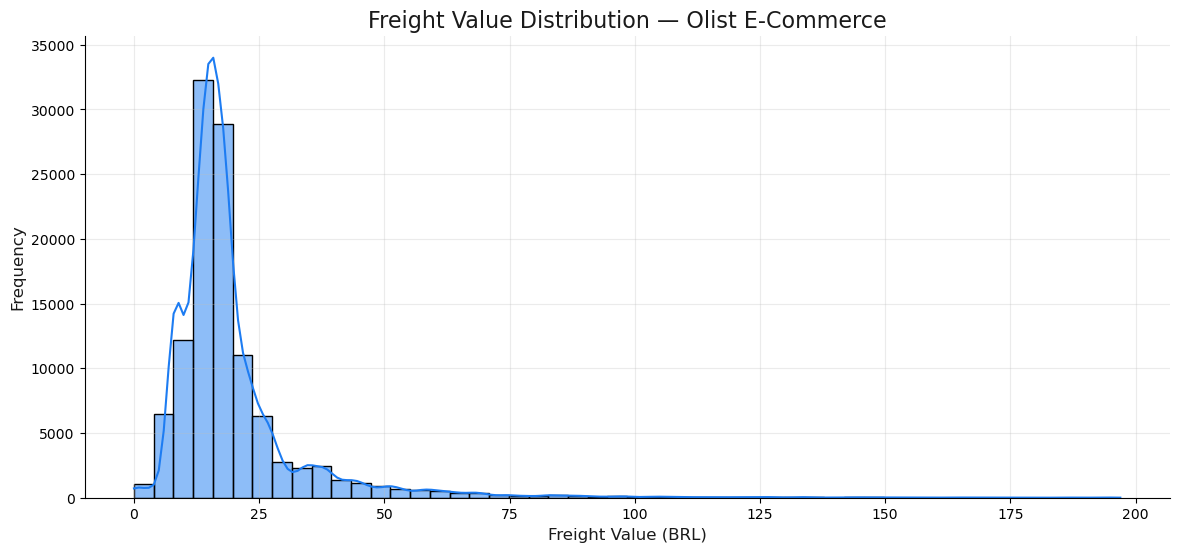

In [78]:
# freight value — basic describe
print("Freight Value — Descriptive Statistics:")
print(orders_full["freight_value"].describe())

# key metrics
mean_freight = orders_full["freight_value"].mean()
median_freight = orders_full["freight_value"].median()
zero_freight = (orders_full["freight_value"] == 0).sum()
high_freight = (orders_full["freight_value"] > 200).sum()

print("\nMean Freight Value:", mean_freight)
print("Median Freight Value:", median_freight)
print("Zero Freight Orders:", zero_freight)
print("Orders > 200 BRL:", high_freight)

# filter outliers
orders_filtered = orders_full[orders_full["freight_value"] <= 200]

# histogram
plt.figure(figsize=(14,6))
sns.histplot(
    data=orders_filtered,
    x="freight_value",
    bins=50,
    kde=True,
    color="#1D7CF2"
)

plt.title("Freight Value Distribution — Olist E-Commerce", fontsize=16, color="#1A1A1A")
plt.xlabel("Freight Value (BRL)", fontsize=12, color="#1A1A1A")
plt.ylabel("Frequency", fontsize=12, color="#1A1A1A")

plt.grid(alpha=0.3, color="#BDBDBD")
sns.despine()

plt.show()


Payment Type Counts:
payment_type
credit_card    87012
boleto         23190
voucher         2180
debit_card      1704
not_defined        3
Name: count, dtype: int64

Payment Type Percentages:
payment_type
credit_card    76.27%
boleto         20.33%
voucher         1.91%
debit_card      1.49%
not_defined     0.00%
Name: proportion, dtype: object


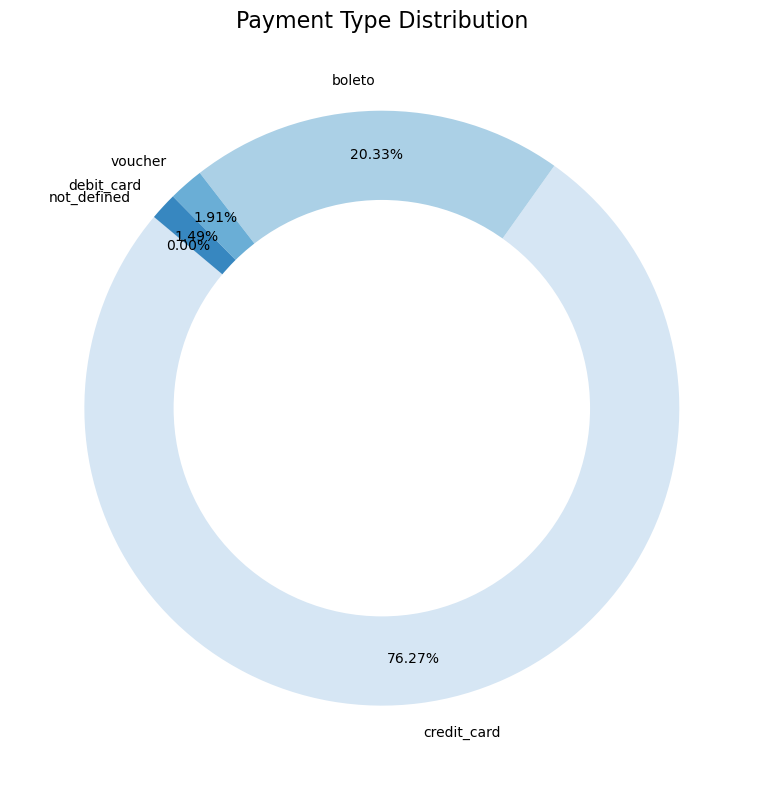

In [18]:
# 1) Count of each payment type
payment_counts = orders_full["payment_type"].value_counts()

# 2) Percentage of each payment type
payment_percent = orders_full["payment_type"].value_counts(normalize=True) * 100
payment_percent_formatted = payment_percent.apply(lambda x: f"{x:.2f}%")
print("Payment Type Counts:")
print(payment_counts)

print("\nPayment Type Percentages:")
print(payment_percent_formatted)

plt.figure(figsize=(8,8))

plt.pie(
    payment_percent.values,
    labels=payment_percent.index,
    autopct=lambda p: f"{p:.2f}%",
    startangle=140,
    pctdistance=0.85,      # يبعد النسبة عن المركز
    labeldistance=1.1,      # يبعد الكلام عن الدايرة
    colors=sns.color_palette("Blues", len(payment_percent))
)

# نضيف دائرة بيضاء صغيرة في النص علشان الشكل يبقى أنيق
centre_circle = plt.Circle((0,0),0.70,fc='white')
fig = plt.gcf()
fig.gca().add_artist(centre_circle)

plt.title("Payment Type Distribution", fontsize=16)
plt.tight_layout()
plt.show()



# ============================================================
# 📌 Final Insights — Orders Overview
# ============================================================

"""
1) Order Status Distribution
----------------------------
- أغلب الطلبات تم توصيلها بنجاح (delivered) وده بيمثل النسبة الأكبر من النظام.
- نسبة صغيرة من الطلبات تم إلغاؤها (canceled) أو فشلت (unavailable / invoiced).
- الطلبات في حالة processing أو shipped تمثل جزء بسيط مقارنة بالطلبات المكتملة.

2) Order Purchase Trends
------------------------
- النشاط الشرائي بيزيد بشكل واضح في منتصف الأسبوع، خصوصًا يومي الثلاثاء والأربعاء.
- نهاية الأسبوع (الجمعة–السبت) أقل في عدد الطلبات.
- شهري نوفمبر ويناير بيظهر فيهم ارتفاع ملحوظ في عدد الطلبات (مواسم تخفيضات).

3) Order Time of Day
---------------------
- أعلى معدل شراء بيكون في الفترة من 1 PM إلى 5 PM.
- الصباح الباكر (قبل 9 AM) أقل فترة نشاط.
- النشاط المسائي موجود لكنه أقل من فترة الظهيرة.

4) Order Value Distribution
---------------------------
- معظم الطلبات قيمتها منخفضة إلى متوسطة.
- الطلبات ذات القيمة العالية قليلة جدًا وتمثل شريحة صغيرة من السوق.
- التوزيع منحاز ناحية الطلبات الصغيرة، مما يعكس طبيعة السوق الاستهلاكي.

5) Freight Value Distribution
-----------------------------
- تكلفة الشحن لمعظم الطلبات منخفضة.
- الطلبات ذات تكلفة شحن عالية نادرة، وغالبًا مرتبطة بمنتجات كبيرة الحجم أو مسافات بعيدة.
- التوزيع skewed ناحية القيم الصغيرة.

6) Payment Type Distribution
----------------------------
- الدفع بالبطاقة الائتمانية هو الأكثر استخدامًا بفارق كبير.
- boleto هو ثاني أكثر وسيلة دفع انتشارًا.
- باقي وسائل الدفع (voucher, debit_card) نسبتها صغيرة.
- not_defined نسبة شبه معدومة.



# ============================================================
# 🚚 Delivery Performance — Final Insights
# ============================================================


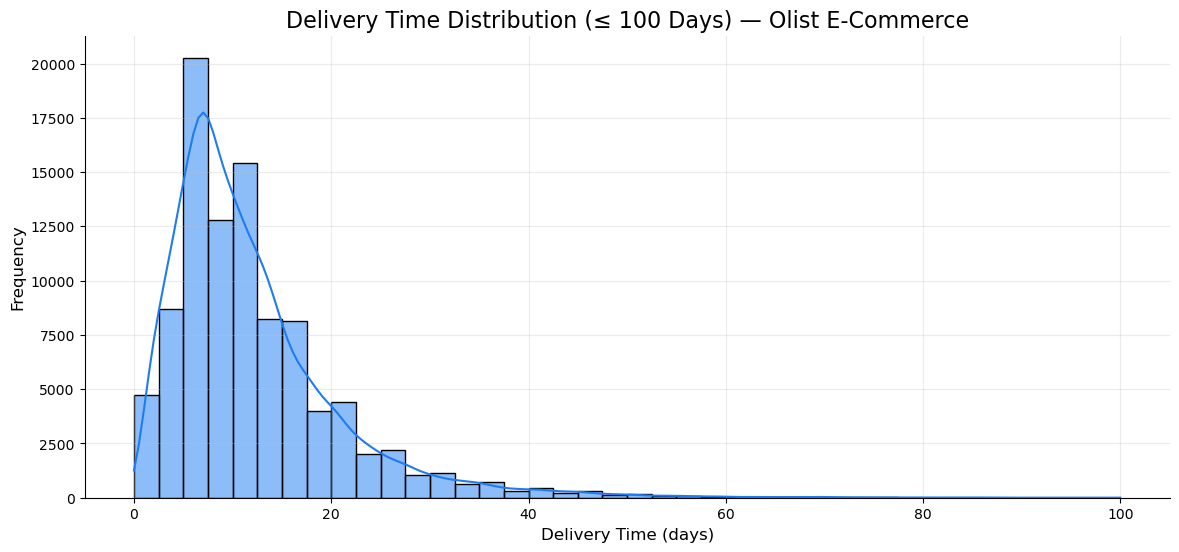

In [19]:
# Actual delivery duration in days
orders["delivery_time_days"] = (
    orders["order_delivered_customer_date"] - orders["order_purchase_timestamp"]
).dt.days

# Remove extreme outliers for a cleaner distribution
filtered_orders = orders[orders["delivery_time_days"] <= 100]

plt.figure(figsize=(14,6))
sns.histplot(
    data=filtered_orders,
    x="delivery_time_days",
    bins=40,
    kde=True,
    color="#1D7CF2"
)

plt.title("Delivery Time Distribution (≤ 100 Days) — Olist E-Commerce", fontsize=16)
plt.xlabel("Delivery Time (days)", fontsize=12)
plt.ylabel("Frequency", fontsize=12)

plt.grid(alpha=0.3, color="#BDBDBD")
sns.despine()

plt.show()


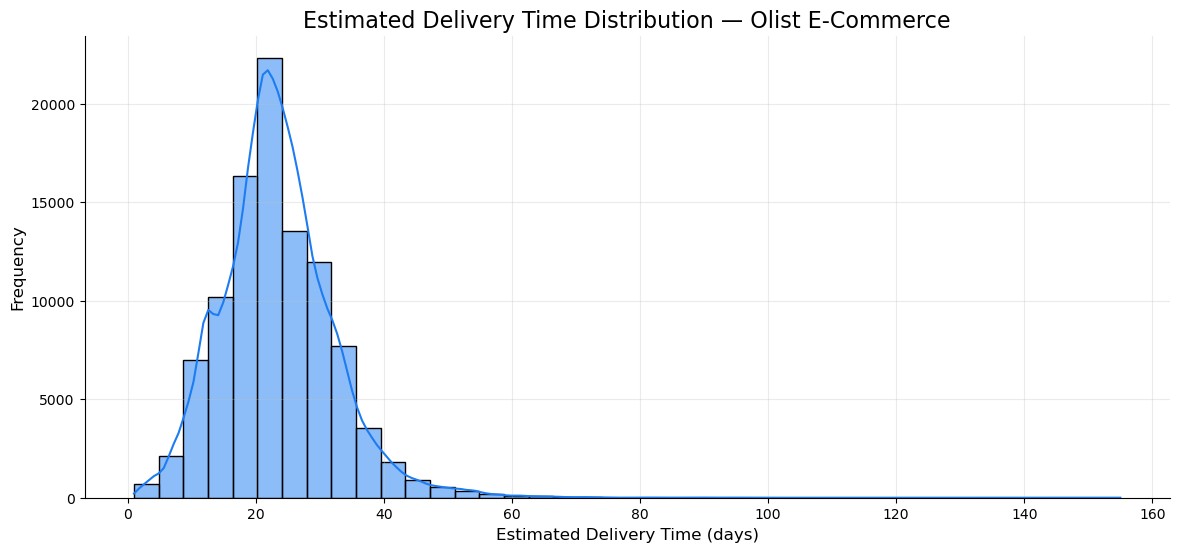

In [20]:
# Estimated delivery duration in days
orders["estimated_time_days"] = (
    orders["order_estimated_delivery_date"] - orders["order_purchase_timestamp"]
).dt.days

plt.figure(figsize=(14,6))
sns.histplot(
    data=orders,
    x="estimated_time_days",
    bins=40,
    kde=True,
    color="#1D7CF2"
)

plt.title("Estimated Delivery Time Distribution — Olist E-Commerce", fontsize=16)
plt.xlabel("Estimated Delivery Time (days)", fontsize=12)
plt.ylabel("Frequency", fontsize=12)

plt.grid(alpha=0.3, color="#BDBDBD")
sns.despine()

plt.show()


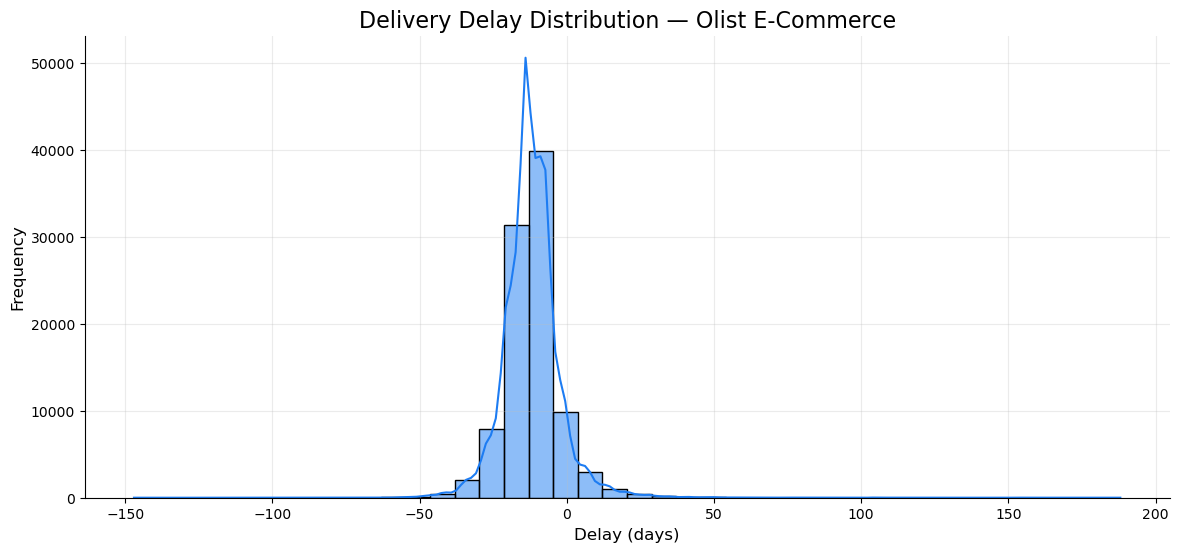

In [21]:
# Delivery delay in days (actual - estimated)
orders["delay_days"] = (
    orders["order_delivered_customer_date"] - orders["order_estimated_delivery_date"]
).dt.days

plt.figure(figsize=(14,6))
sns.histplot(
    data=orders,
    x="delay_days",
    bins=40,
    kde=True,
    color="#1D7CF2"
)

plt.title("Delivery Delay Distribution — Olist E-Commerce", fontsize=16)
plt.xlabel("Delay (days)", fontsize=12)
plt.ylabel("Frequency", fontsize=12)

plt.grid(alpha=0.3, color="#BDBDBD")
sns.despine()

plt.show()


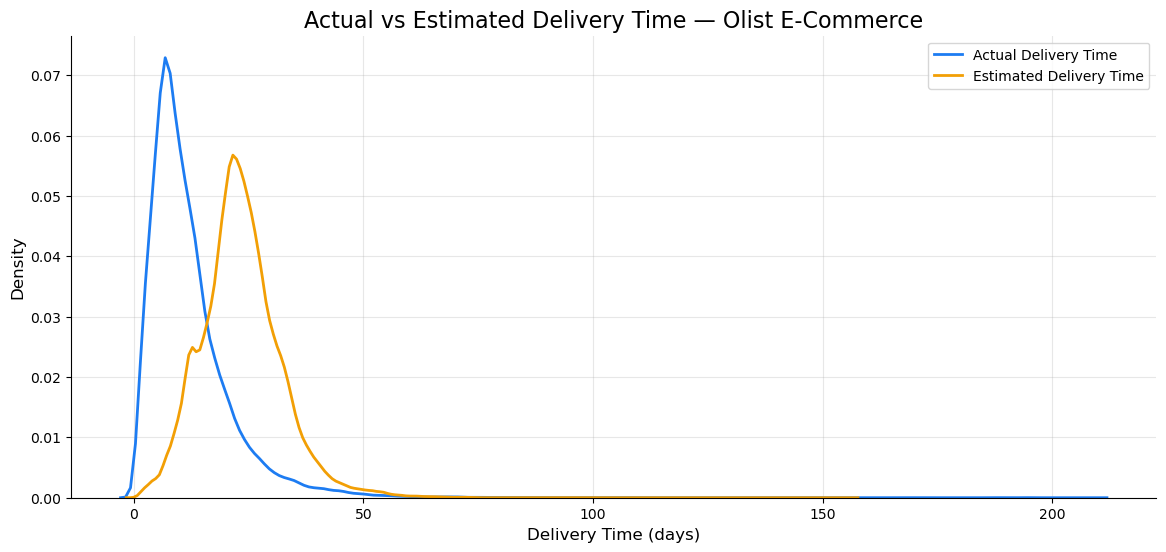

In [22]:
# Actual vs Estimated delivery time
plt.figure(figsize=(14,6))

sns.kdeplot(
    data=orders,
    x="delivery_time_days",
    label="Actual Delivery Time",
    color="#1D7CF2",
    linewidth=2
)

sns.kdeplot(
    data=orders,
    x="estimated_time_days",
    label="Estimated Delivery Time",
    color="#F29F05",
    linewidth=2
)

plt.title("Actual vs Estimated Delivery Time — Olist E-Commerce", fontsize=16)
plt.xlabel("Delivery Time (days)", fontsize=12)
plt.ylabel("Density", fontsize=12)

plt.grid(alpha=0.3)
plt.legend()
sns.despine()

plt.show()


C:\Users\amira\AppData\Local\Temp\ipykernel_17896\1808847942.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


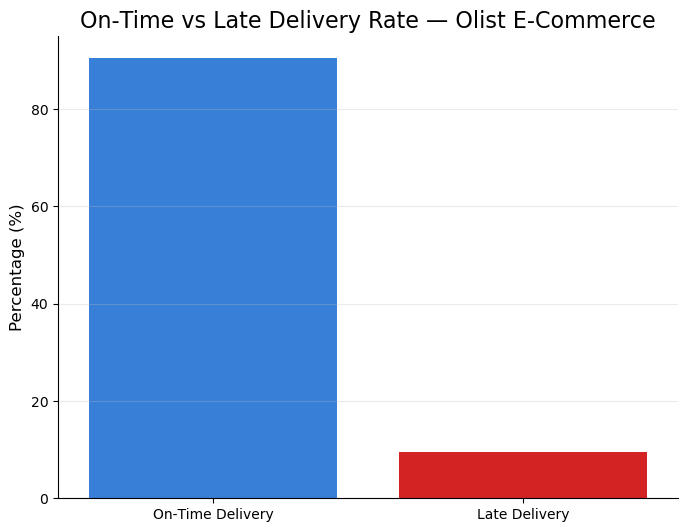

On‑Time Delivery Rate: 90.45%
Late Delivery Rate: 9.55%


In [23]:
# On‑time delivery flag (True = delivered on or before estimated date)
orders["on_time"] = orders["delay_days"] <= 0

# On‑time and late delivery percentages
on_time_rate = orders["on_time"].mean() * 100
late_rate = 100 - on_time_rate

plt.figure(figsize=(8,6))
sns.barplot(
    x=["On‑Time Delivery", "Late Delivery"],
    y=[on_time_rate, late_rate],
    palette=["#1D7CF2", "#F20505"]
)

plt.title("On‑Time vs Late Delivery Rate — Olist E-Commerce", fontsize=16)
plt.ylabel("Percentage (%)", fontsize=12)

plt.grid(axis="y", alpha=0.3, color="#BDBDBD")
sns.despine()

plt.show()

print(f"On‑Time Delivery Rate: {on_time_rate:.2f}%")
print(f"Late Delivery Rate: {late_rate:.2f}%")


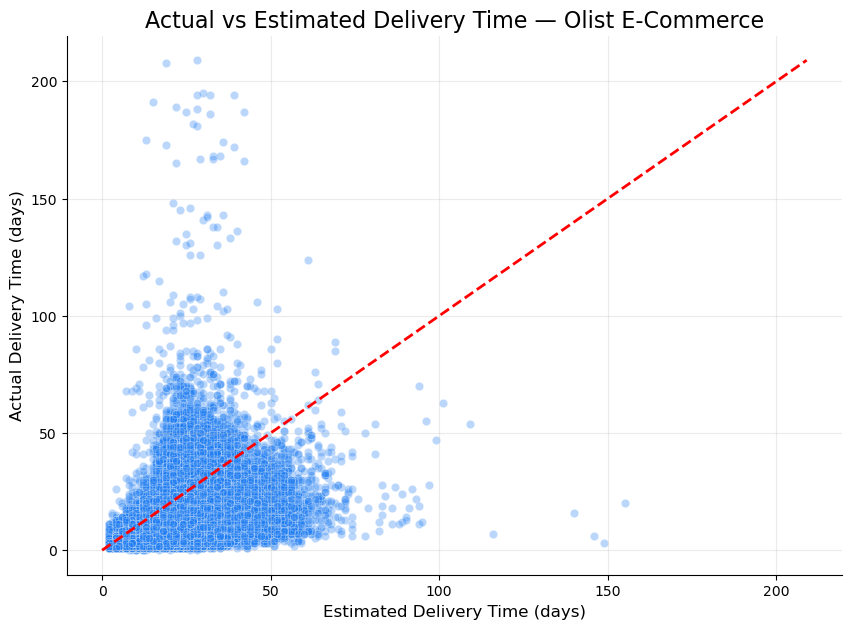

In [24]:
# Compare actual vs estimated delivery duration
plt.figure(figsize=(10,7))

sns.scatterplot(
    data=orders,
    x="estimated_time_days",
    y="delivery_time_days",
    alpha=0.3,
    color="#1D7CF2"
)

# Reference line (perfect estimation)
max_val = max(orders["estimated_time_days"].max(), orders["delivery_time_days"].max())
plt.plot([0, max_val], [0, max_val], color="red", linestyle="--", linewidth=2)

plt.title("Actual vs Estimated Delivery Time — Olist E-Commerce", fontsize=16)
plt.xlabel("Estimated Delivery Time (days)", fontsize=12)
plt.ylabel("Actual Delivery Time (days)", fontsize=12)

plt.grid(alpha=0.3, color="#BDBDBD")
sns.despine()

plt.show()


In [25]:
# Convert dates and calculate delivery time
orders_full["order_delivered_customer_date"] = pd.to_datetime(orders_full["order_delivered_customer_date"])
orders_full["order_purchase_timestamp"] = pd.to_datetime(orders_full["order_purchase_timestamp"])

orders_full["delivery_time_days"] = (
    orders_full["order_delivered_customer_date"] - orders_full["order_purchase_timestamp"]
).dt.days


C:\Users\amira\AppData\Local\Temp\ipykernel_17896\2072787148.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


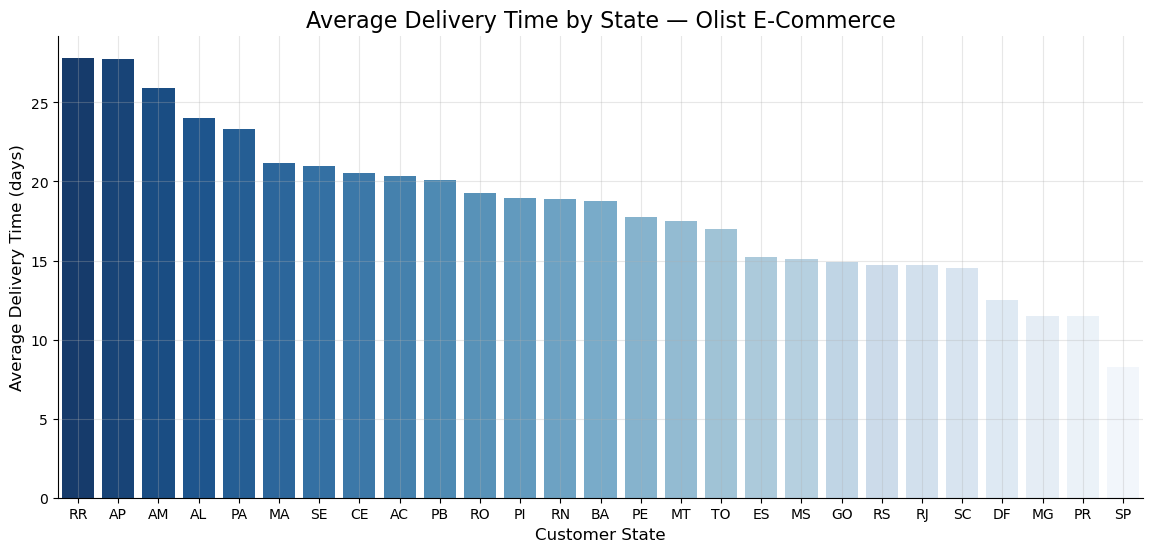

In [26]:
# Average delivery time per state
Delivery_Time_by_State = (
    orders_full.groupby("customer_state")["delivery_time_days"]
    .mean()
    .reset_index()
    .sort_values(by="delivery_time_days", ascending=False)
)

# Bar chart
plt.figure(figsize=(14,6))
sns.barplot(
    data=Delivery_Time_by_State,
    x="customer_state",
    y="delivery_time_days",
    palette="Blues_r"
)

plt.title("Average Delivery Time by State — Olist E-Commerce", fontsize=16)
plt.xlabel("Customer State", fontsize=12)
plt.ylabel("Average Delivery Time (days)", fontsize=12)

plt.grid(alpha=0.3)
sns.despine()
plt.show()


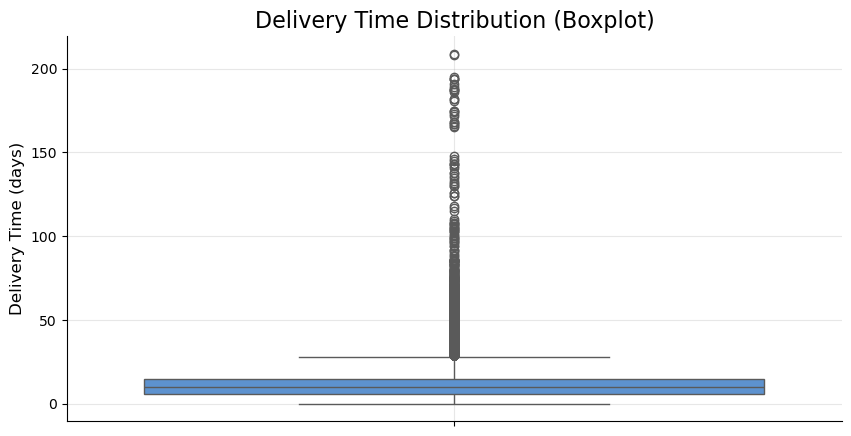

In [27]:
plt.figure(figsize=(10,5))

sns.boxplot(
    data=orders_full,
    y="delivery_time_days",
    color="#4A90E2"
)

plt.title("Delivery Time Distribution (Boxplot)", fontsize=16)
plt.ylabel("Delivery Time (days)", fontsize=12)

plt.grid(alpha=0.3)
sns.despine()
plt.show()


# ============================================================
# 📌 Final Insights — Delivery Performance
# ============================================================

"""
1) Delivery Time by State
-------------------------
- ولايات الشمال والشمال الشرقي (RR, AP, AM, PA) بتسجّل أعلى أوقات توصيل.
- ولايات الجنوب والجنوب الشرقي (SP, PR, MG, SC) هي الأسرع في التوصيل.
- البعد الجغرافي عن مراكز التوزيع الأساسية بيأثر بشكل واضح على سرعة الشحن.

2) Delivery Time Distribution (Boxplot)
---------------------------------------
- أغلب الطلبات بتوصل خلال 0–20 يوم.
- وجود Outliers مرتفعة تتجاوز 100 يوم يشير لمشاكل لوجستية استثنائية.
- التوزيع skewed ناحية القيم الكبيرة بسبب الطلبات المتأخرة جدًا.

3) Actual vs Estimated Delivery Time
------------------------------------
- التوصيل الفعلي أبطأ من التقدير المتوقع.
- منحنى Actual منحرف لليمين → تأخير أكبر من المتوقع.
- نظام التقدير محتاج تحسين ليعكس الأداء الحقيقي.

4) Overall Delivery Performance
-------------------------------
- الأداء العام مستقر لكن فيه نسبة صغيرة من الطلبات المتأخرة جدًا.
- تحسين دقة التقدير + معالجة الحالات الشاذة = رفع رضا العملاء.
- التركيز على الولايات البعيدة قد يقلل متوسط وقت التوصيل العام.
"""


# ============================================================
# 📌 Final Insights — Customers Overview
# ============================================================


<Figure size 1200x1000 with 0 Axes>

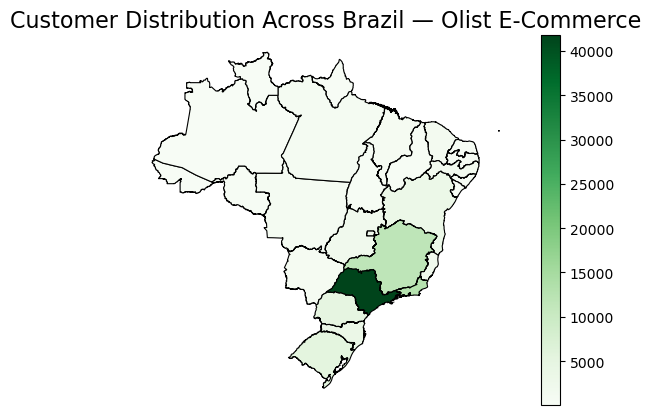

In [28]:
# Download Brazil states GeoJSON
import requests

url = "https://raw.githubusercontent.com/codeforamerica/click_that_hood/master/public/data/brazil-states.geojson"
response = requests.get(url)

with open("brazil_states.geojson", "wb") as f:
    f.write(response.content)

# Read Brazil map
brazil_map = gpd.read_file("brazil_states.geojson")

# Customer count per state
customers_by_state = (
    customers.groupby("customer_state")["customer_id"]
    .nunique()
    .reset_index()
    .rename(columns={"customer_id": "customer_count"})
)

# Merge map with customer data
brazil_map = brazil_map.merge(
    customers_by_state,
    left_on="sigla",
    right_on="customer_state",
    how="left"
)

# Plot map
plt.figure(figsize=(12,10))
brazil_map.plot(
    column="customer_count",
    cmap="Greens",
    linewidth=0.8,
    edgecolor="black",
    legend=True
)

plt.title("Customer Distribution Across Brazil — Olist E-Commerce", fontsize=16)
plt.axis("off")
plt.show()


In [29]:
# Number of unique customers
customers["customer_id"].nunique()


99441

C:\Users\amira\AppData\Local\Temp\ipykernel_17896\1977071998.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=city_counts, x="count", y="city", palette="viridis")


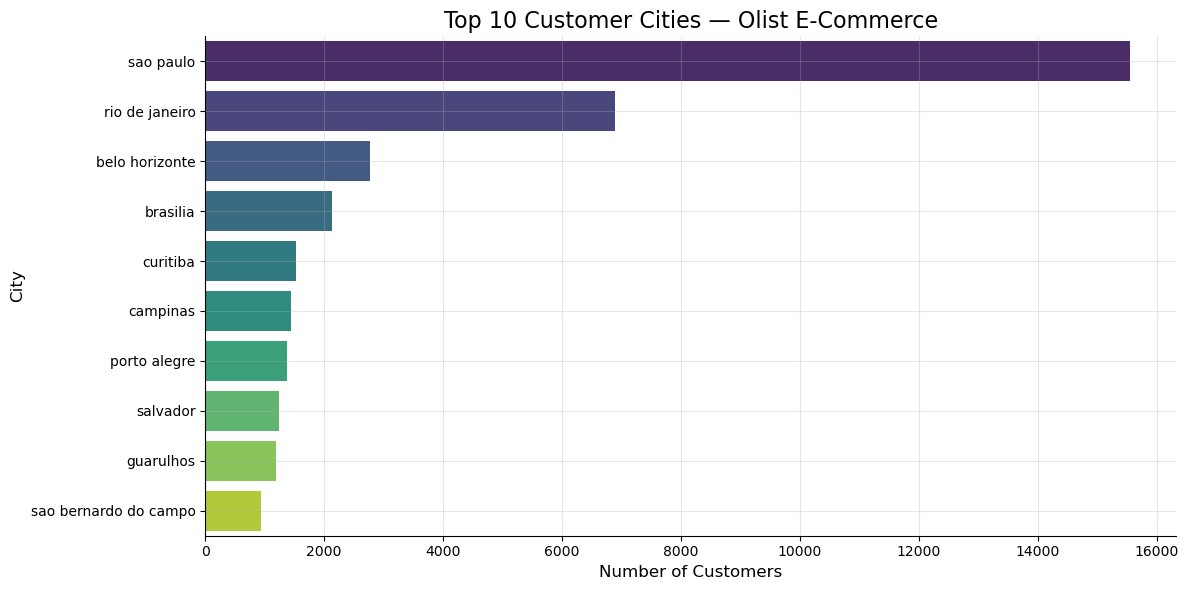

In [30]:
# Top 10 customer cities
city_counts = (
    customers["customer_city"]
    .value_counts()
    .head(10)
    .reset_index()
)
city_counts.columns = ["city", "count"]

# Bar chart
plt.figure(figsize=(12,6))
sns.barplot(data=city_counts, x="count", y="city", palette="viridis")

plt.title("Top 10 Customer Cities — Olist E-Commerce", fontsize=16)
plt.xlabel("Number of Customers", fontsize=12)
plt.ylabel("City", fontsize=12)

plt.grid(alpha=0.3)
sns.despine()
plt.tight_layout()
plt.show()


# ============================================================
# 📌 Final Insights — Customers Overview
# ============================================================

"""
1) Customer Base Size
---------------------
- عدد العملاء كبير ويمثل قاعدة مستخدمين واسعة داخل المنصة.
- وجود عدد كبير من العملاء بيدعم قوة الطلب على مستوى البرازيل.
- العدد المرتفع يعكس انتشار المنصة وقدرتها على الوصول لشرائح مختلفة.

2) Customer Distribution Across States
--------------------------------------
- العملاء موزعين على معظم ولايات البرازيل.
- ولاية São Paulo تمتلك أعلى عدد من العملاء بفارق واضح.
- التركّز في الولايات الحضرية الكبرى يعكس اعتماد المنصة على المناطق ذات الكثافة السكانية العالية.

3) Top 10 Customer Cities
-------------------------
- أعلى 10 مدن تمثل نسبة كبيرة من إجمالي العملاء.
- مدينة São Paulo هي الأكثر تمثيلًا بفارق كبير عن باقي المدن.
- وجود مدن متوسطة الحجم ضمن القائمة يعكس انتشار جيد خارج العاصمة.
"""


# ============================================================
# 📌 Products Overview
# ============================================================


C:\Users\amira\AppData\Local\Temp\ipykernel_17896\1305921925.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


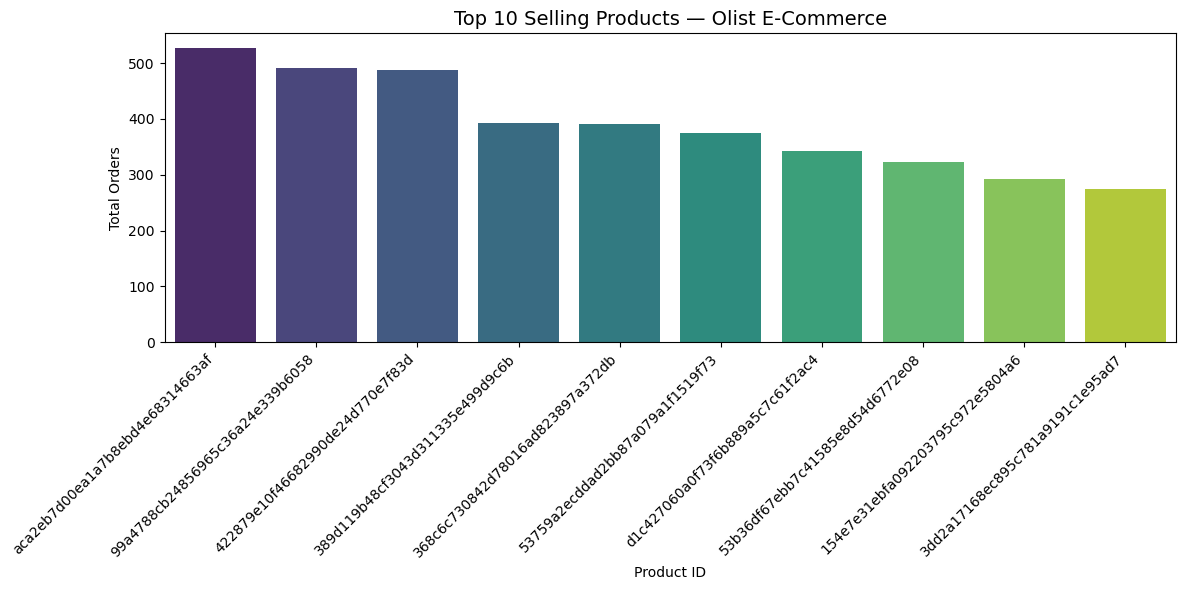

In [32]:
# Top 10 selling products (by number of orders)
top_selling_products = (
    orders_full.groupby("product_id")["order_id"]
    .count()
    .reset_index()
    .rename(columns={"order_id": "total_orders"})
    .sort_values("total_orders", ascending=False)
    .head(10)
)
# Top 10 selling products chart
plt.figure(figsize=(12,6))

sns.barplot(
    data=top_selling_products,
    x="product_id",
    y="total_orders",
    palette="viridis"
)

plt.title("Top 10 Selling Products — Olist E-Commerce", fontsize=14)
plt.xlabel("Product ID")
plt.ylabel("Total Orders")
plt.xticks(rotation=45, ha="right")

plt.tight_layout()
plt.show()


C:\Users\amira\AppData\Local\Temp\ipykernel_17896\2121923859.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


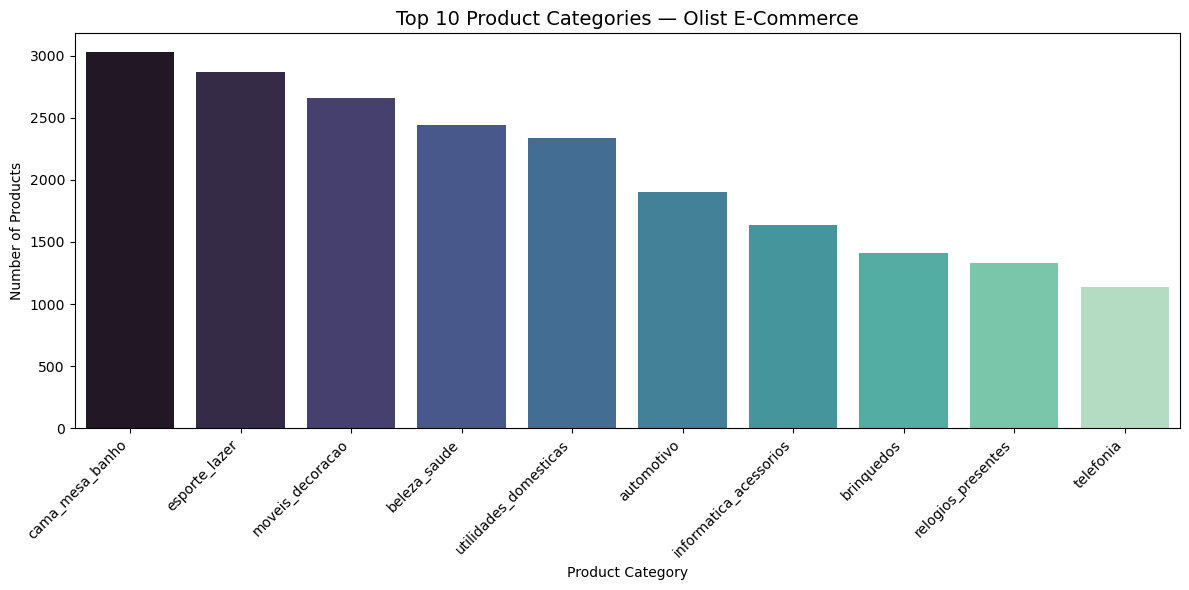

In [33]:
# Top 10 product categories (by number of products)
products_category_distribution = (
    products.groupby("product_category_name")["product_id"]
    .count()
    .reset_index()
    .rename(columns={"product_id": "total_products"})
    .sort_values("total_products", ascending=False)
    .head(10)
)
# Top 10 product categories chart
plt.figure(figsize=(12,6))

sns.barplot(
    data=products_category_distribution,
    x="product_category_name",
    y="total_products",
    palette="mako"
)

plt.title("Top 10 Product Categories — Olist E-Commerce", fontsize=14)
plt.xlabel("Product Category")
plt.ylabel("Number of Products")
plt.xticks(rotation=45, ha="right")

plt.tight_layout()
plt.show()


  price_range  percentage
0        0–50   34.901909
1      50–100   29.312028
2     100–200   23.913893
3     200–500    9.017310
4        >500    2.854860


C:\Users\amira\AppData\Local\Temp\ipykernel_17896\1076993549.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=temp, x="price_range", y="percentage", palette="crest")


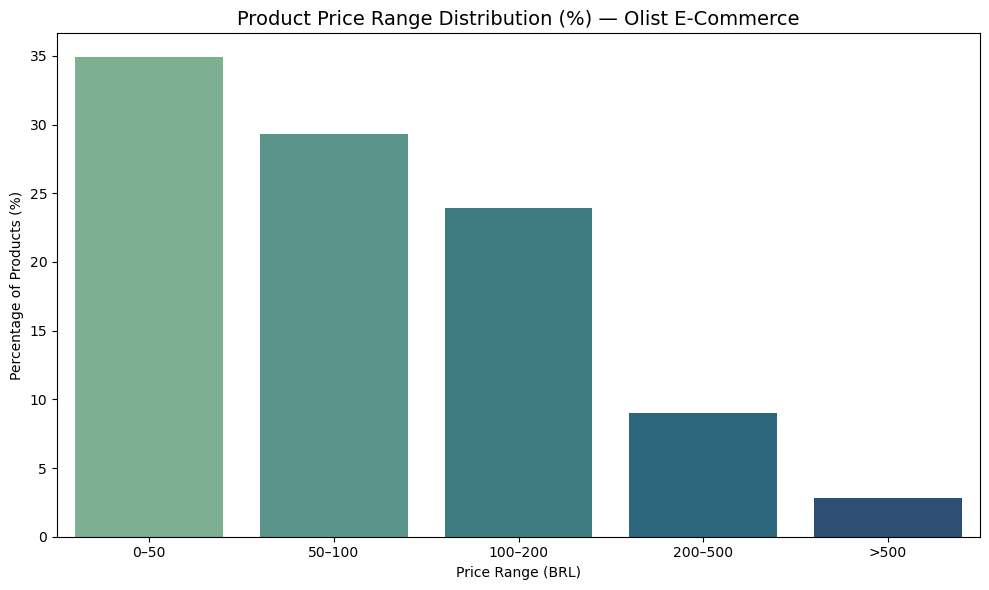

In [34]:
# Create price bins
bins = [0, 50, 100, 200, 500, order_items["price"].max()]
labels = ["0–50", "50–100", "100–200", "200–500", ">500"]

# Assign price ranges
order_items["price_range"] = pd.cut(order_items["price"], bins=bins, labels=labels, include_lowest=True)

# Percentage distribution
temp = order_items["price_range"].value_counts(normalize=True).reset_index()
temp.columns = ["price_range", "percentage"]
temp = temp.sort_values("price_range")
temp["percentage"] *= 100

print(temp)

# Plot
plt.figure(figsize=(10,6))
sns.barplot(data=temp, x="price_range", y="percentage", palette="crest")

plt.title("Product Price Range Distribution (%) — Olist E-Commerce", fontsize=14)
plt.xlabel("Price Range (BRL)")
plt.ylabel("Percentage of Products (%)")

plt.tight_layout()
plt.show()


                         product_id  product_weight_g  product_volume
0  1e9e8ef04dbcff4541ed26657ea517e5             225.0          2240.0
1  3aa071139cb16b67ca9e5dea641aaa2f            1000.0         10800.0
2  96bd76ec8810374ed1b65e291975717f             154.0          2430.0
3  cef67bcfe19066a932b7673e239eb23d             371.0          2704.0
4  9dc1a7de274444849c219cff195d0b71             625.0          4420.0


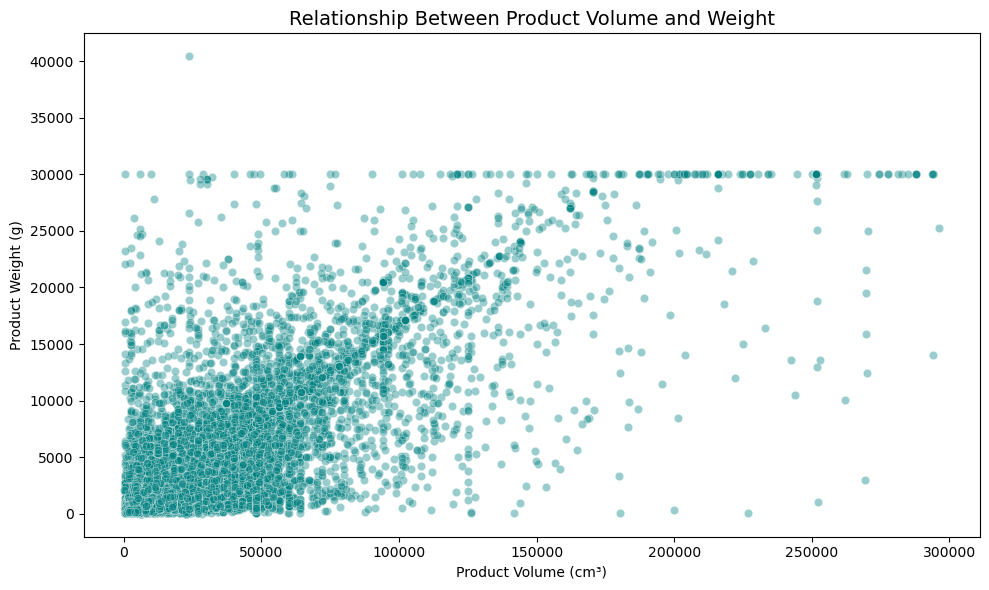

In [35]:
# Create product volume (cm³)
products["product_volume"] = (
    products["product_length_cm"] *
    products["product_height_cm"] *
    products["product_width_cm"]
)

# Preview
print(products[["product_id", "product_weight_g", "product_volume"]].head())

# Scatterplot: volume vs weight
plt.figure(figsize=(10,6))

sns.scatterplot(
    data=products,
    x="product_volume",
    y="product_weight_g",
    alpha=0.4,
    color="teal"
)

plt.title("Relationship Between Product Volume and Weight", fontsize=14)
plt.xlabel("Product Volume (cm³)")
plt.ylabel("Product Weight (g)")

plt.tight_layout()
plt.show()


                             product_id  total_orders
22112  aca2eb7d00ea1a7b8ebd4e68314663af           527
19742  99a4788cb24856965c36a24e339b6058           488
8613   422879e10f46682990de24d770e7f83d           484
7364   389d119b48cf3043d311335e499d9c6b           392
7079   368c6c730842d78016ad823897a372db           388
10840  53759a2ecddad2bb87a079a1f1519f73           373
27039  d1c427060a0f73f6b889a5c7c61f2ac4           343
10867  53b36df67ebb7c41585e8d54d6772e08           323
2794   154e7e31ebfa092203795c972e5804a6           281
8051   3dd2a17168ec895c781a9191c1e95ad7           274


C:\Users\amira\AppData\Local\Temp\ipykernel_17896\910449095.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


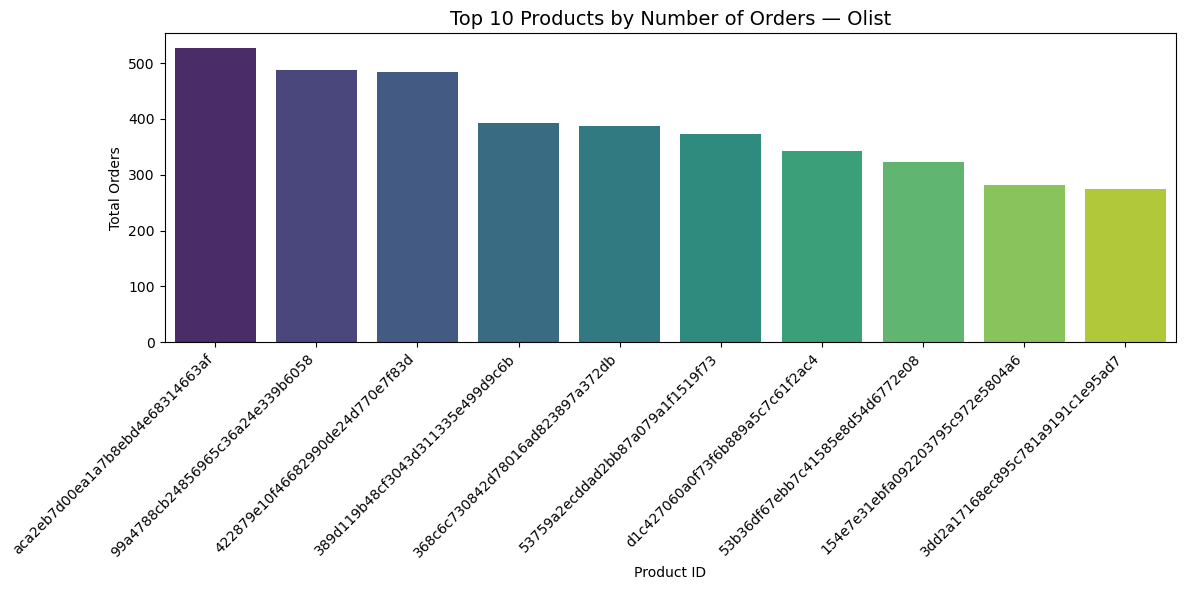

In [36]:
# Count orders per product
top_products_orders = (
    order_items.groupby("product_id")["order_id"]
    .count()
    .reset_index()
    .rename(columns={"order_id": "total_orders"})
    .sort_values("total_orders", ascending=False)
    .head(10)
)

print(top_products_orders)

# Plot
plt.figure(figsize=(12,6))
sns.barplot(
    data=top_products_orders,
    x="product_id",
    y="total_orders",
    palette="viridis"
)

plt.title("Top 10 Products by Number of Orders — Olist", fontsize=14)
plt.xlabel("Product ID")
plt.ylabel("Total Orders")
plt.xticks(rotation=45, ha="right")

plt.tight_layout()
plt.show()


                             product_id   revenue
24086  bb50f2e236e5eea0100680137654686c  63885.00
14068  6cdd53843498f92890544667809f1595  54730.20
27613  d6160fb7873f184099d9bc95e30376af  48899.34
27039  d1c427060a0f73f6b889a5c7c61f2ac4  47214.51
19742  99a4788cb24856965c36a24e339b6058  43025.56
8051   3dd2a17168ec895c781a9191c1e95ad7  41082.60
4996   25c38557cf793876c5abdd5931f922db  38907.32
12351  5f504b3a1c75b73d6151be81eb05bdc9  37733.90
10867  53b36df67ebb7c41585e8d54d6772e08  37683.42
22112  aca2eb7d00ea1a7b8ebd4e68314663af  37608.90


C:\Users\amira\AppData\Local\Temp\ipykernel_17896\2855402647.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


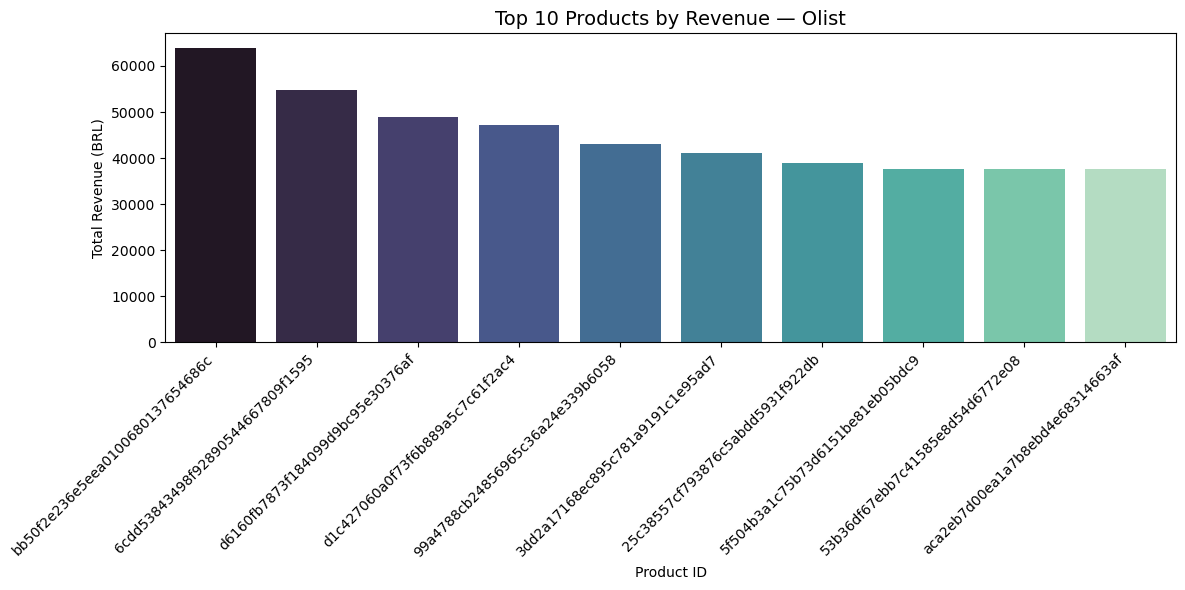

In [37]:
# Calculate revenue per product
top_products_revenue = (
    order_items.assign(revenue = order_items["price"])
    .groupby("product_id")["revenue"]
    .sum()
    .reset_index()
    .sort_values("revenue", ascending=False)
    .head(10)
)

print(top_products_revenue)

# Plot
plt.figure(figsize=(12,6))
sns.barplot(
    data=top_products_revenue,
    x="product_id",
    y="revenue",
    palette="mako"
)

plt.title("Top 10 Products by Revenue — Olist", fontsize=14)
plt.xlabel("Product ID")
plt.ylabel("Total Revenue (BRL)")
plt.xticks(rotation=45, ha="right")

plt.tight_layout()
plt.show()


                             product_id  quantity_sold
22112  aca2eb7d00ea1a7b8ebd4e68314663af            527
19742  99a4788cb24856965c36a24e339b6058            488
8613   422879e10f46682990de24d770e7f83d            484
7364   389d119b48cf3043d311335e499d9c6b            392
7079   368c6c730842d78016ad823897a372db            388
10840  53759a2ecddad2bb87a079a1f1519f73            373
27039  d1c427060a0f73f6b889a5c7c61f2ac4            343
10867  53b36df67ebb7c41585e8d54d6772e08            323
2794   154e7e31ebfa092203795c972e5804a6            281
8051   3dd2a17168ec895c781a9191c1e95ad7            274


C:\Users\amira\AppData\Local\Temp\ipykernel_17896\2558541463.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


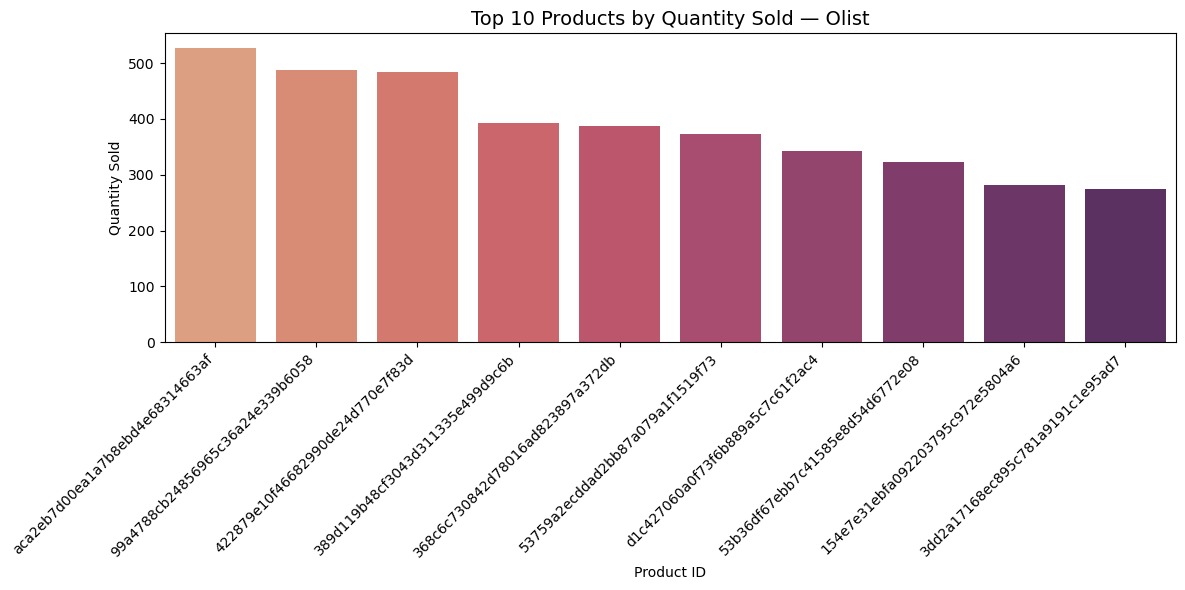

In [38]:
# Quantity sold per product
top_products_qty = (
    order_items.groupby("product_id")["order_item_id"]
    .count()
    .reset_index()
    .rename(columns={"order_item_id": "quantity_sold"})
    .sort_values("quantity_sold", ascending=False)
    .head(10)
)

print(top_products_qty)

# Plot
plt.figure(figsize=(12,6))
sns.barplot(
    data=top_products_qty,
    x="product_id",
    y="quantity_sold",
    palette="flare"
)

plt.title("Top 10 Products by Quantity Sold — Olist", fontsize=14)
plt.xlabel("Product ID")
plt.ylabel("Quantity Sold")
plt.xticks(rotation=45, ha="right")

plt.tight_layout()
plt.show()


# ============================================================
# 📌 Final Insights — Products Overview
# ============================================================

"""
1) Product Categories
---------------------
- فئة cama_mesa_banho هي الأكثر انتشارًا من حيث عدد المنتجات.
- بعدها فئات esporte_lazer و moveis_decoracao مما يعكس اهتمام المستخدمين بالمنزل والترفيه.
- الفئات الأقل مثل telefonia و relogios_presentes تمثل نيش صغير داخل المنصة.

2) Product Price Insights
-------------------------
- أغلب المنتجات أسعارها أقل من 200 BRL مما يعكس طبيعة سوق اقتصادي.
- التوزيع منحرف يمينًا (Right-skewed) بسبب وجود منتجات قليلة مرتفعة السعر.
- حوالي 35% من المنتجات أقل من 50 BRL، و29% بين 50–100 BRL.
- المنتجات فوق 500 BRL تمثل فقط 3% من السوق.

3) Weight & Volume Insights
---------------------------
- علاقة شبه خطية بين الوزن والحجم، مما يعكس منطقية البيانات.
- وجود Outliers لمنتجات وزنها كبير مقارنة بحجمها → قد تكون منتجات معدنية أو أخطاء إدخال.
- توزيع الأبعاد (Length/Height/Width) طبيعي مع وجود قيم شاذة في الأطراف.

4) Product Performance
----------------------
- المنتج aca2eb7d00ea1a7b8ebd4e68314663af هو الأعلى في عدد الطلبات والكمية المباعة.
- المنتج bb50f2e2365eea0100680137654866c هو الأعلى في الإيراد بسبب سعره المرتفع.
- السوق يعتمد على منتجات شعبية منخفضة السعر لتحقيق حجم مبيعات كبير.

5) Overall Insight
------------------
- منصة Olist تعتمد على منتجات اقتصادية عالية الطلب.
- الإيرادات العالية تأتي من منتجات قليلة Premium.
- التركيز الأكبر على فئات منزلية وترفيهية، مما يعكس سلوك المستهلك البرازيلي.
"""


# ============================================================
# 📌 Reviews Overview
# ============================================================


C:\Users\amira\AppData\Local\Temp\ipykernel_17896\1333848803.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


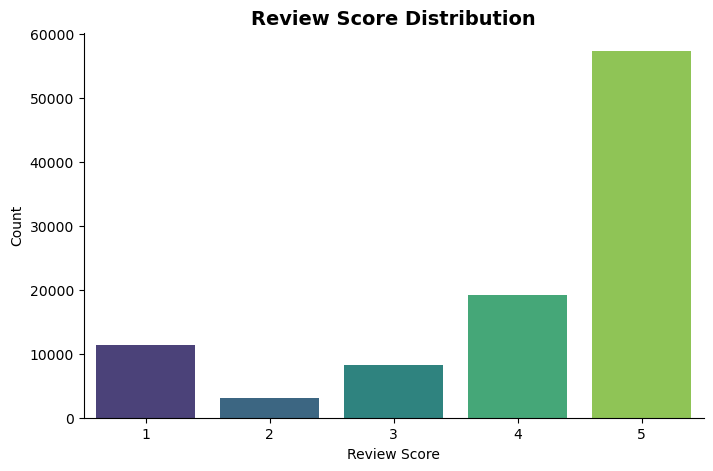

In [43]:
# Plot review score distribution
plt.figure(figsize=(8,5))
sns.countplot(
    data=reviews,
    x="review_score",
    palette="viridis",
    order=sorted(reviews["review_score"].unique())
)

plt.title("Review Score Distribution", fontsize=14, weight="bold")
plt.xlabel("Review Score")
plt.ylabel("Count")
sns.despine()
plt.show()


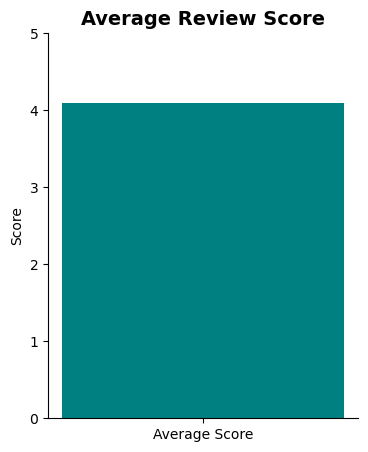

In [45]:
# Calculate average review score
avg_score = reviews["review_score"].mean().round(2)
# Plot average review score
plt.figure(figsize=(4,5))
plt.bar(["Average Score"], [avg_score], color="teal")
plt.ylim(0,5)
plt.title("Average Review Score", fontsize=14, weight="bold")
plt.ylabel("Score")
sns.despine()
plt.show()


C:\Users\amira\AppData\Local\Temp\ipykernel_17896\3303025090.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


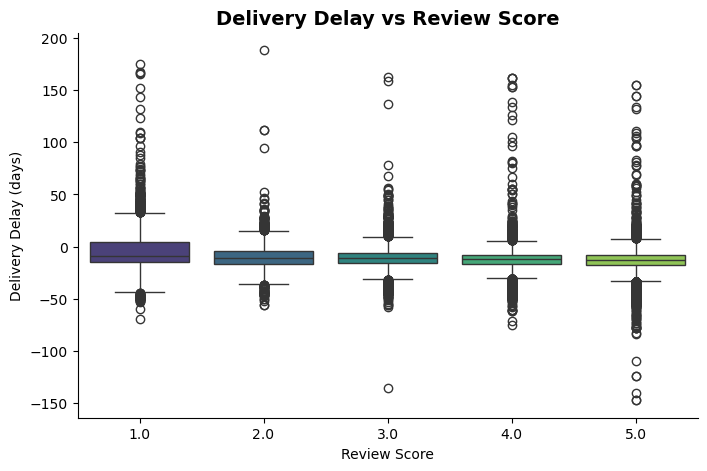

In [54]:
# Convert date columns to datetime
orders_full["order_delivered_customer_date"] = pd.to_datetime(orders_full["order_delivered_customer_date"])
orders_full["order_estimated_delivery_date"] = pd.to_datetime(orders_full["order_estimated_delivery_date"])

# Calculate delay in days
orders_full["delay_days"] = (
    orders_full["order_delivered_customer_date"] - orders_full["order_estimated_delivery_date"]
).dt.days

# Plot delivery delay vs review score
plt.figure(figsize=(8,5))
sns.boxplot(
    data=orders_full,
    x="review_score",
    y="delay_days",
    palette="viridis"
)

plt.title("Delivery Delay vs Review Score", fontsize=14, weight="bold")
plt.xlabel("Review Score")
plt.ylabel("Delivery Delay (days)")
sns.despine()
plt.show()


# ============================================================
# 📌 Final Insights — Reviews Overview
# ============================================================

"""
1) Average Review Score
-----------------------
- متوسط تقييمات العملاء حوالي 4.1 من 5، مما يعكس رضا عام مرتفع جدًا.
- يشير إلى أن تجربة المستخدم في المنصة إيجابية ومستقرة.
- رغم وجود بعض التأخيرات في التوصيل، إلا أن الانطباع العام ممتاز.

2) Review Score Distribution
----------------------------
- أغلب العملاء يمنحون تقييم 5 نجوم، وهو ما يمثل أكثر من نصف المراجعات.
- التقييمات المنخفضة (1 و2) نسبتها محدودة جدًا، مما يدل على جودة الخدمة.
- التوزيع منحاز للتقييمات العالية → السوق يتمتع بثقة العملاء واستقرار الأداء.

3) Delivery Delay vs Review Score
---------------------------------
- الطلبات المتأخرة غالبًا مرتبطة بتقييمات منخفضة (1 و2).
- الطلبات التي وصلت في الوقت أو قبل الموعد حصلت على تقييمات مرتفعة (4 و5).
- العلاقة العكسية بين التأخير والتقييم تؤكد أن سرعة التوصيل عامل رئيسي في رضا العميل.
- وجود Outliers يشير لحالات تأخير استثنائية تستحق تحليل تشغيلي منفصل.

4) Overall Insight
------------------
- رضا العملاء مرتفع جدًا، لكن التأخير في التوصيل يؤثر سلبًا على التقييمات.
- تحسين الأداء اللوجيستي سيزيد من متوسط التقييم العام ويقلل التقييمات المنخفضة.
- المنصة تتمتع بثقة قوية من العملاء، مما يعكس نجاح تجربة الشراء الإجمالية.
"""


# ============================================================
# 📌 Category Mix & Order Composition
# ============================================================


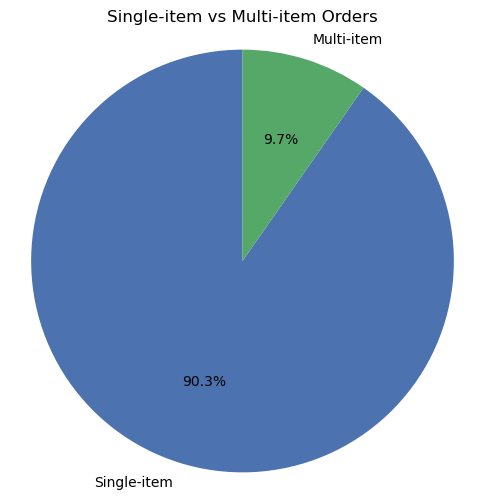

In [62]:
# count number of products per order
order_product_count = (
    order_items.groupby("order_id")["product_id"]
    .count()
    .reset_index(name="product_count")
)

# classify orders: single-item vs multi-item
order_product_count["order_type"] = order_product_count["product_count"].apply(
    lambda x: "Single-item" if x == 1 else "Multi-item"
)

# calculate percentage of each order type
order_type_stats = (
    order_product_count["order_type"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
    .reset_index()
)

order_type_stats.columns = ["order_type", "percentage"]


# values from your summary
labels = ["Single-item", "Multi-item"]
sizes = [88863, 9547]
colors = ["#4C72B0", "#55A868"]  # same palette we use

plt.figure(figsize=(6,6))
plt.pie(sizes, labels=labels, autopct="%1.1f%%", startangle=90, colors=colors)
plt.title("Single-item vs Multi-item Orders")
plt.axis("equal")
plt.show()



# ============================================================
# 📌 Final Insights — Category Mix & Order Composition
# ============================================================

"""
1) Order Composition Overview
-----------------------------
- حوالي 90% من الطلبات تحتوي على منتج واحد فقط، مما يعكس سلوك شراء مباشر وغير تجميعي.
- حوالي 10% فقط من الطلبات تحتوي على أكثر من منتج، وهي نسبة صغيرة لكنها تمثل فرصًا مهمة للـ cross‑sell.
- هذا التوزيع يوضح أن معظم العملاء يدخلون المنصة بهدف شراء منتج محدد وليس استكشاف فئات متعددة.

2) Single-item vs Multi-item Orders
-----------------------------------
- Single-item Orders تمثل السلوك السائد في السوق، مما يشير إلى أن تجربة الشراء تعتمد على احتياج واحد واضح.
- Multi-item Orders رغم قلتها، إلا أنها تكشف عن فئة من العملاء لديهم استعداد لشراء منتجات مكملة.
- فهم هذا التوزيع يساعد في تحديد الفئات التي يمكن استهدافها بعروض Bundles أو توصيات مخصصة.

3) Business Insight
-------------------
- سيطرة الطلبات ذات المنتج الواحد تعني أن فرص زيادة الـ AOV تعتمد على تحسين الـ cross‑sell داخل صفحة المنتج.
- الطلبات متعددة المنتجات تمثل الشريحة الأكثر قيمة، ويمكن استغلالها في بناء Bundles مبنية على الفئات الأكثر تكرارًا.
- التركيز على المنتجات أو الفئات التي تظهر في الطلبات متعددة المنتجات قد يرفع من معدل التحويل ويزيد من متوسط قيمة السلة.

4) Overall Interpretation
-------------------------
- السوق يميل إلى الشراء المباشر، لكن هناك مساحة واضحة لتطوير استراتيجيات Bundling.
- تحسين تجربة التصفح وربط المنتجات المكملة قد يزيد من نسبة الطلبات متعددة المنتجات.
- التحليل يوضح أن Category Behavior يلعب دورًا مهمًا في فهم فرص النمو داخل المنصة.
"""
